# 04 — Modèles Avancés

## Objectif
Construire des modèles avancés qui surpassent nos baselines. La référence à battre est le **MAPE 2.55%** (Régression Linéaire). L'objectif final est d'avoir un **MAPE < 2%**.

## Stratégie
1. Entraîner XGBoost avec optimisation des hyperparamètres
2. Entraîner LSTM
3. Comparer les deux sur le set de validation

In [1]:
# ============================================================
# 04 — MODÈLES AVANCÉS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
%matplotlib inline

# Chargement du dataset final
df = pd.read_csv('../data/processed/pjme_final.csv',
                 index_col='Datetime',
                 parse_dates=True)

# Split train / validation / test
FEATURES = [col for col in df.columns if col != 'PJME']
TARGET = 'PJME'

split_train_val = '2016-01-01'
split_val_test  = '2018-01-01'

train = df[df.index < split_train_val]
val   = df[(df.index >= split_train_val) & (df.index < split_val_test)]
test  = df[df.index >= split_val_test]

X_train, y_train = train[FEATURES], train[TARGET]
X_val,   y_val   = val[FEATURES],   val[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(" Données chargées")
print(f"Train      : {len(train):,} heures")
print(f"Validation : {len(val):,} heures")
print(f"Test       : {len(test):,} heures")

# Fonction d'évaluation
def evaluer_modele(y_reel, y_pred, nom_modele):
    mape = np.mean(np.abs((y_reel - y_pred) / y_reel)) * 100
    mae  = mean_absolute_error(y_reel, y_pred)
    rmse = np.sqrt(mean_squared_error(y_reel, y_pred))
    print(f"\n{'='*40}")
    print(f"  {nom_modele}")
    print(f"{'='*40}")
    print(f"  MAPE  : {mape:.2f}%")
    print(f"  MAE   : {mae:,.0f} MW")
    print(f"  RMSE  : {rmse:,.0f} MW")
    print(f"{'='*40}")
    return {'modele': nom_modele, 'MAPE': mape, 'MAE': mae, 'RMSE': rmse}

resultats = {}

 Données chargées
Train      : 113,950 heures
Validation : 17,544 heures
Test       : 5,136 heures


## 1️ XGBoost
- Gère très bien les features tabulaires (nos 34 features)
- Robuste aux outliers
- Rapide à entraîner même sur 100k+ lignes
- Pas besoin de normalisation contrairement à la régression linéaire

### Hyperparamètres importants
| Paramètre | Rôle |
|-----------|------|
| `n_estimators` | Nombre d'arbres |
| `max_depth` | Profondeur maximale des arbres |
| `learning_rate` | Vitesse d'apprentissage |
| `subsample` | Fraction des données utilisées par arbre |

On entraine le modèle avec des paramètres par défaut, puis optimiser avec une recherche sur grille.

In [2]:
# ============================================================
# XGBoost — Modèle initial
# ============================================================

model_xgb = xgb.XGBRegressor(
    n_estimators  = 1000,
    learning_rate = 0.05,
    max_depth     = 6,
    subsample     = 0.8,
    random_state  = 42,
    n_jobs        = -1,
    early_stopping_rounds = 50,
    eval_metric   = 'rmse'
)

print("Entraînement en cours...")
model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

y_pred_xgb = model_xgb.predict(X_val)

resultats['XGBoost'] = evaluer_modele(
    y_val, y_pred_xgb, 'XGBoost (défaut)'
)

Entraînement en cours...
[0]	validation_0-rmse:6219.15001
[100]	validation_0-rmse:434.96850
[200]	validation_0-rmse:352.75384
[300]	validation_0-rmse:326.94874
[400]	validation_0-rmse:312.49661
[500]	validation_0-rmse:302.19587
[600]	validation_0-rmse:295.63477
[700]	validation_0-rmse:290.40708
[800]	validation_0-rmse:286.36322
[900]	validation_0-rmse:282.95138
[999]	validation_0-rmse:280.68506

  XGBoost (défaut)
  MAPE  : 0.65%
  MAE   : 202 MW
  RMSE  : 281 MW


MAPE de 0.65%, ce qui est encore mieux que la régression linéaire (2.55%). Le RMSE continue de baisser jusqu'à l'itération 999 donc le modèle n'a pas encore convergé, il pourrait encore s'améliorer avec plus d'arbres. De plus on est passé de 6219 RMSE à 281 RMSE en 1000 arbres, ce qui est une amélioration massive.

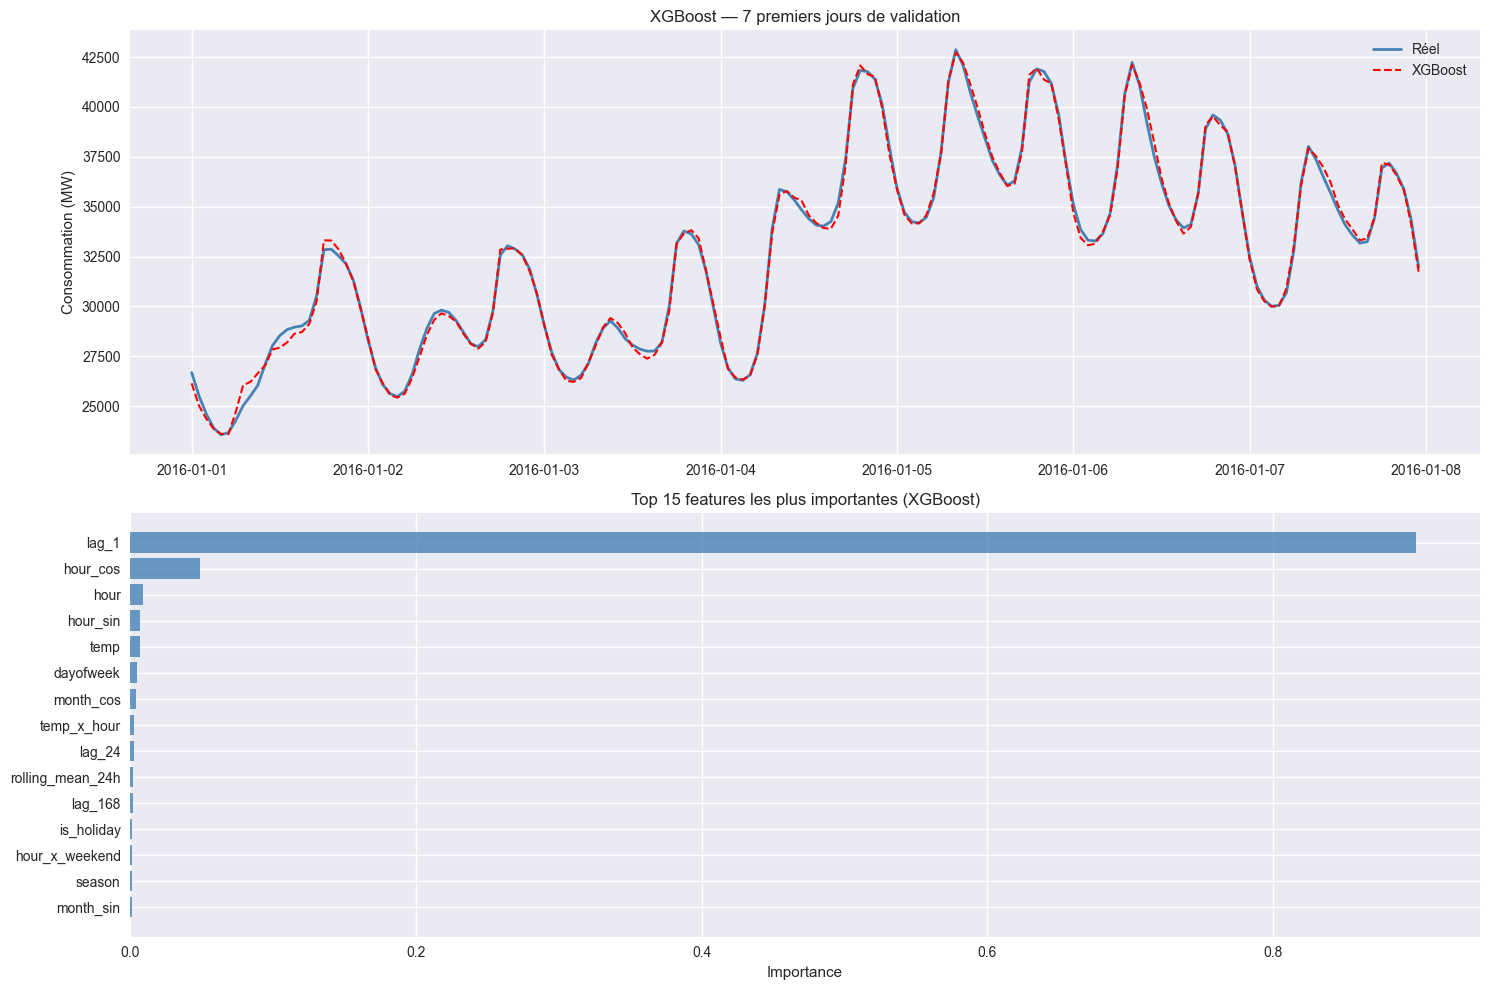

In [3]:
# ============================================================
# Visualisation XGBoost
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# --- Graphique 1 : 7 premiers jours ---
axes[0].plot(y_val[:168].index, y_val[:168].values,
             label='Réel', color='steelblue', linewidth=2)
axes[0].plot(y_val[:168].index, y_pred_xgb[:168],
             label='XGBoost', color='red',
             linewidth=1.5, linestyle='--')
axes[0].set_title('XGBoost — 7 premiers jours de validation')
axes[0].set_ylabel('Consommation (MW)')
axes[0].legend()

# --- Graphique 2 : importance des features ---
feat_imp = pd.Series(
    model_xgb.feature_importances_,
    index=FEATURES
).sort_values(ascending=True).tail(15)

axes[1].barh(feat_imp.index, feat_imp.values, color='steelblue', alpha=0.8)
axes[1].set_title('Top 15 features les plus importantes (XGBoost)')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

La courbe rouge suit quasi parfaitement la courbe bleue. C'est cohérent avec un MAPE de 0.65%. lag_1 domine massivement (~0.90) ie la consommation de l'heure précédente est de loin la feature la plus prédictive. hour_cos arrive loin derrière (~0.07) ie l'encodage cyclique de l'heure est utile. temp, dayofweek, lag_24 contribuent modestement.

La domination de lag_1 est normale pour H+1 car on prédit l'heure suivante et la valeur actuelle est très proche. Mais pour H+24, lag_1 ne sera probablement pas disponible.

##  Optimisation des hyperparamètres XGBoost

On teste différentes combinaisons d'hyperparamètres pour trouver le meilleur modèle. On va utiliser ici une recherche aléatoire (RandomizedSearchCV).

In [ ]:
# ============================================================
# Optimisation des hyperparamètres — RandomizedSearchCV
# ============================================================

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

# Grille de paramètres à explorer
param_grid = {
    'n_estimators'  : [500, 1000, 1500],
    'max_depth'     : [4, 6, 8],
    'learning_rate' : [0.01, 0.05, 0.1],
    'subsample'     : [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# TimeSeriesSplit 
tscv = TimeSeriesSplit(n_splits=3)

xgb_base = xgb.XGBRegressor(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=20,
    cv=tscv,
    scoring='neg_mean_absolute_percentage_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Recherche des meilleurs hyperparamètres...")
search.fit(X_train, y_train)

print(f"\n Meilleurs paramètres :")
print(search.best_params_)

Recherche des meilleurs hyperparamètres...
(peut prendre 5-10 minutes)

Fitting 3 folds for each of 20 candidates, totalling 60 fits

 Meilleurs paramètres :
{'subsample': 0.9, 'n_estimators': 1500, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.9}


Ces hyperparamètres sont bons mais on va entrainé le modèle optimisé pour avoir probablement des hyperparamètres encore plus meilleurs.

In [ ]:
# ============================================================
# XGBoost optimisé avec les meilleurs hyperparamètres
# ============================================================

model_xgb_opt = xgb.XGBRegressor(
    n_estimators     = 1500,
    max_depth        = 8,
    learning_rate    = 0.05,
    subsample        = 0.9,
    colsample_bytree = 0.9,
    random_state     = 42,
    n_jobs           = -1,
    early_stopping_rounds = 50,
    eval_metric      = 'rmse'
)

print("Entraînement du modèle optimisé...")
model_xgb_opt.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

y_pred_xgb_opt = model_xgb_opt.predict(X_val)

resultats['XGBoost Optimisé'] = evaluer_modele(
    y_val, y_pred_xgb_opt, 'XGBoost Optimisé'
)

# Comparaison avec le modèle de base
print(f"\n Gain vs XGBoost de base :")
mape_base = resultats['XGBoost']['MAPE']
mape_opt  = resultats['XGBoost Optimisé']['MAPE']
print(f"  XGBoost de base  : {mape_base:.2f}%")
print(f"  XGBoost optimisé : {mape_opt:.2f}%")
print(f"  Amélioration     : {mape_base - mape_opt:.2f} points")

Entraînement du modèle optimisé...
[0]	validation_0-rmse:6216.33283
[100]	validation_0-rmse:384.60439
[200]	validation_0-rmse:324.91789
[300]	validation_0-rmse:308.09851
[400]	validation_0-rmse:299.88548
[500]	validation_0-rmse:294.79227
[600]	validation_0-rmse:292.17250
[700]	validation_0-rmse:289.71474
[800]	validation_0-rmse:287.78337
[900]	validation_0-rmse:286.47759
[1000]	validation_0-rmse:285.29163
[1100]	validation_0-rmse:284.21379
[1200]	validation_0-rmse:283.31567
[1300]	validation_0-rmse:282.54184
[1400]	validation_0-rmse:281.96450
[1499]	validation_0-rmse:281.74095

  XGBoost Optimisé
  MAPE  : 0.64%
  MAE   : 203 MW
  RMSE  : 282 MW

📊 Gain vs XGBoost de base :
  XGBoost de base  : 0.65%
  XGBoost optimisé : 0.64%
  Amélioration     : 0.00 points


Le gain est quasi nul (0.01 point) donc le modèle de base était déjà quasi optimal. Le RMSE continue de baisser jusqu'à l'itération 1499 sans jamais se stabiliser ce qui suggère que le modèle pourrait encore s'améliorer avec plus d'arbres, mais le gain marginal devient très faible.

Le modèle de base avec 1000 arbres est donc suffisant. L'optimisation n'apporte presque rien, on est déjà probablement à la limite des performances atteignables avec ces features.

## 2️ LSTM (Long Short-Term Memory)

Le LSTM est un réseau de neurones qui traite des **séquences** 
de données temporelles. Contrairement à XGBoost qui voit chaque heure 
indépendamment, le LSTM reçoit une fenêtre de 48 heures consécutives 
et apprend les patterns dans cette séquence.

### Architecture retenue
- Fenêtre temporelle : 48 heures
- 2 couches LSTM (64 et 32 neurones)
- 1 couche Dense de sortie
- Dropout pour éviter le surapprentissage

In [6]:
# ============================================================
# Préparation des données pour LSTM
# ============================================================

from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f"TensorFlow version : {tf.__version__}")

# Normalisation (obligatoire pour les réseaux de neurones)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled   = scaler_X.transform(X_val)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_val_scaled   = scaler_y.transform(y_val.values.reshape(-1, 1)).flatten()

# Création des séquences (fenêtre de 48h)
WINDOW = 48

def creer_sequences(X, y, window):
    """Transforme les données tabulaires en séquences pour le LSTM."""
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i-window:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = creer_sequences(X_train_scaled, y_train_scaled, WINDOW)
X_val_seq,   y_val_seq   = creer_sequences(X_val_scaled,   y_val_scaled,   WINDOW)

print(f"Shape X_train_seq : {X_train_seq.shape}")
print(f"Shape X_val_seq   : {X_val_seq.shape}")
print(f"\nInterprétation : (échantillons, fenêtre temporelle, features)")

TensorFlow version : 2.21.0
Shape X_train_seq : (113902, 48, 34)
Shape X_val_seq   : (17496, 48, 34)

Interprétation : (échantillons, fenêtre temporelle, features)


On commence par 2 fréquences vu que nos patterns sont réguliers et bien définis et surtout pour éviter le surapprentissage. On rajoutera d'autres séquence au cas ou les résultats seront pas suffisants.

In [7]:
# ============================================================
# Construction du modèle LSTM
# ============================================================

model_lstm = Sequential([
    LSTM(64, return_sequences=True, 
         input_shape=(WINDOW, X_train_seq.shape[2])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model_lstm.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model_lstm.summary()

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1
)

# Entraînement

history = model_lstm.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=512,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 48, 64)         │        25,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,305 (149.63 KB)

 Trainable params: 38,305 (149.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 138s 563ms/step - loss: 0.1426 - mae: 0.2696 - val_loss: 0.0382 - val_mae: 0.1484 - learning_rate: 0.0010
Epoch 2/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 113s 507ms/step - loss: 0.0426 - mae: 0.1579 - val_loss: 0.0227 - val_mae: 0.1137 - learning_rate: 0.0010
Epoch 3/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 113s 507ms/step - loss: 0.0319 - mae: 0.1361 - val_loss: 0.0185 - val_mae: 0.1027 - learning_rate: 0.0010
Epoch 4/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 117s 526ms/step - loss: 0.0267 - mae: 0.1241 - val_loss: 0.0159 - val_mae: 0.0948 - learning_rate: 0.0010
Epoch 5/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 87s 389ms/step - loss: 0.0237 - mae: 0.1165 - val_loss: 0.0143 - val_mae: 0.0910 - learning_rate: 0.0010
Epoch 6/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 80s 361ms/step - loss: 0.0213 - mae: 0.1102 - val_loss: 0.0140 - val_mae: 0.0911 - learning_rate: 0.0010
Epoch 7/50
223/223 ━━━━━━━━━━━━━━━━━━━━ 88s 396ms/step - loss: 0.0196 - mae: 0.1055 - val_loss: 0.0131 - val_mae: 0.0876 - lea

L'early stopping s'est déclenché à l'epoch 29 et a restauré les poids de l'epoch 19, le meilleur modèle. Maintenant étudions les performances du modèle.

547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step

  LSTM
  MAPE  : 1.75%
  MAE   : 527 MW
  RMSE  : 673 MW


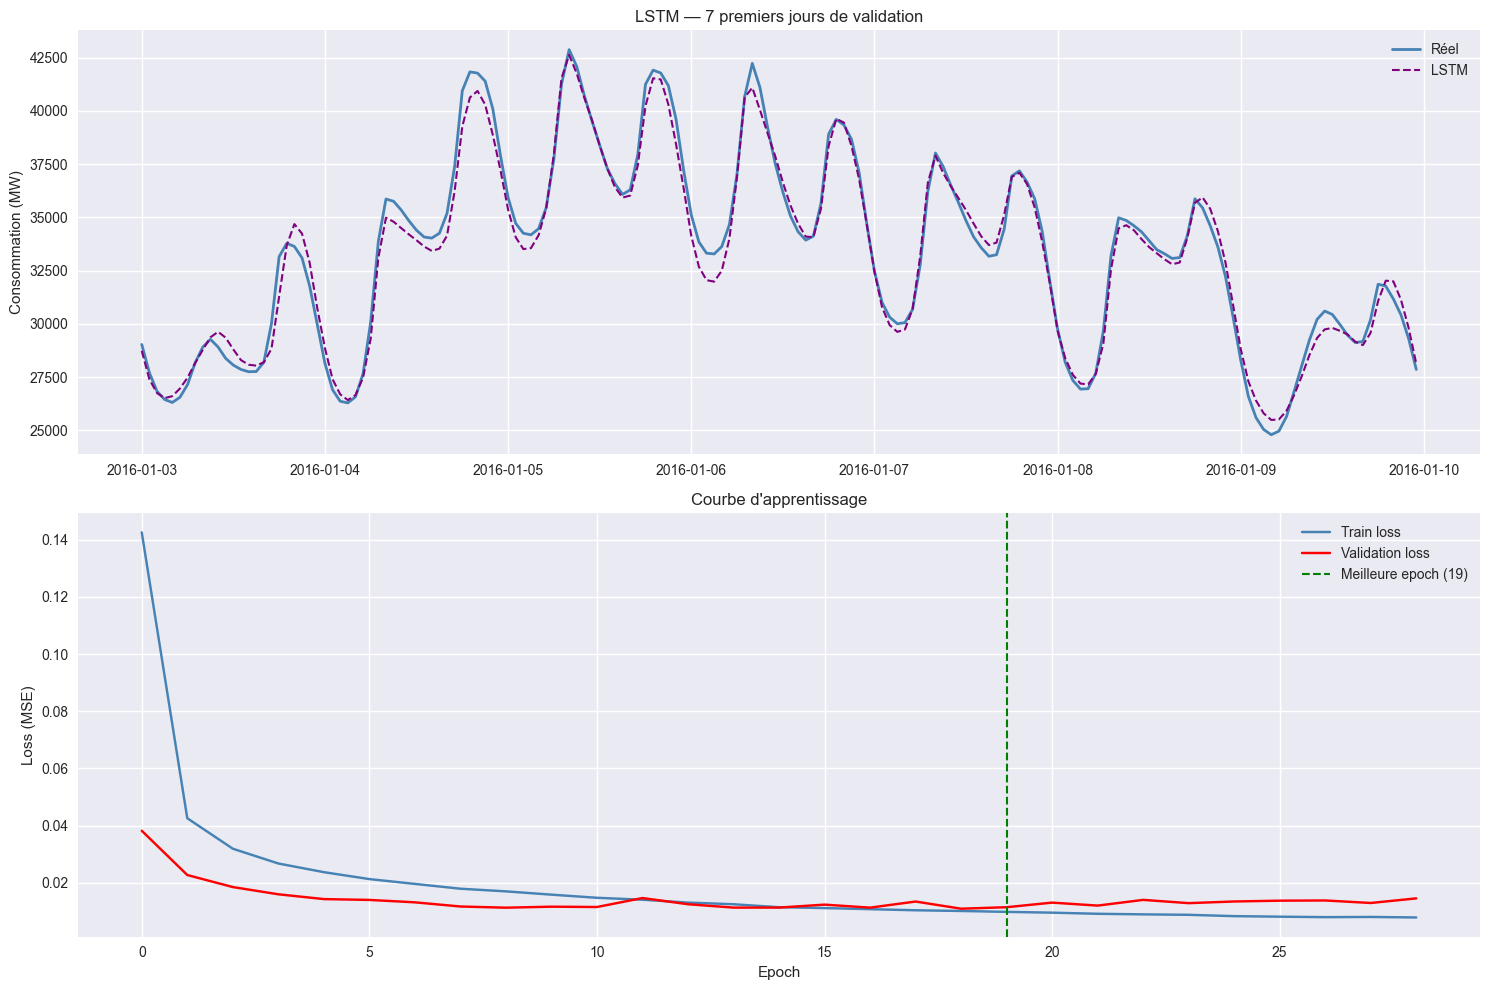

In [8]:
# ============================================================
# Évaluation du LSTM
# ============================================================

# Prédictions sur la validation
y_pred_lstm_scaled = model_lstm.predict(X_val_seq)

# Dénormalisation
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled).flatten()

# Alignement des index (les 48 premières heures sont perdues (fenêtre))
y_val_lstm = y_val.values[WINDOW:]

resultats['LSTM'] = evaluer_modele(
    y_val_lstm, y_pred_lstm, 'LSTM'
)

# Visualisation sur 7 jours
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Graphique 1 : prédictions vs réel
axes[0].plot(y_val.index[WINDOW:WINDOW+168], y_val_lstm[:168],
             label='Réel', color='steelblue', linewidth=2)
axes[0].plot(y_val.index[WINDOW:WINDOW+168], y_pred_lstm[:168],
             label='LSTM', color='purple',
             linewidth=1.5, linestyle='--')
axes[0].set_title('LSTM — 7 premiers jours de validation')
axes[0].set_ylabel('Consommation (MW)')
axes[0].legend()

# Graphique 2 : courbe d'apprentissage
axes[1].plot(history.history['loss'],
             label='Train loss', color='steelblue')
axes[1].plot(history.history['val_loss'],
             label='Validation loss', color='red')
axes[1].axvline(x=19, color='green', linestyle='--',
                linewidth=1.5, label='Meilleure epoch (19)')
axes[1].set_title('Courbe d\'apprentissage')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (MSE)')
axes[1].legend()

plt.tight_layout()
plt.show()

Le MAPE 1.75%, c'est un bon résultat et l'objectif < 3% est atteint, mais nettement moins bon que XGBoost (0.65%).

La courbe d'apprentissage est très saine car la validation loss descend rapidement puis se stabilise. Pas de surapprentissage visible. L'early stopping à l'epoch 19 était bien justifié.

=== COMPARAISON FINALE ===
             Modèle  MAPE  MAE  RMSE
     Moyenne Mobile 11.71 3543  4438
    Naïf Saisonnier  6.78 2125  2917
Régression Linéaire  2.55  797  1015
               LSTM  1.75  527   673
            XGBoost  0.65  202   281


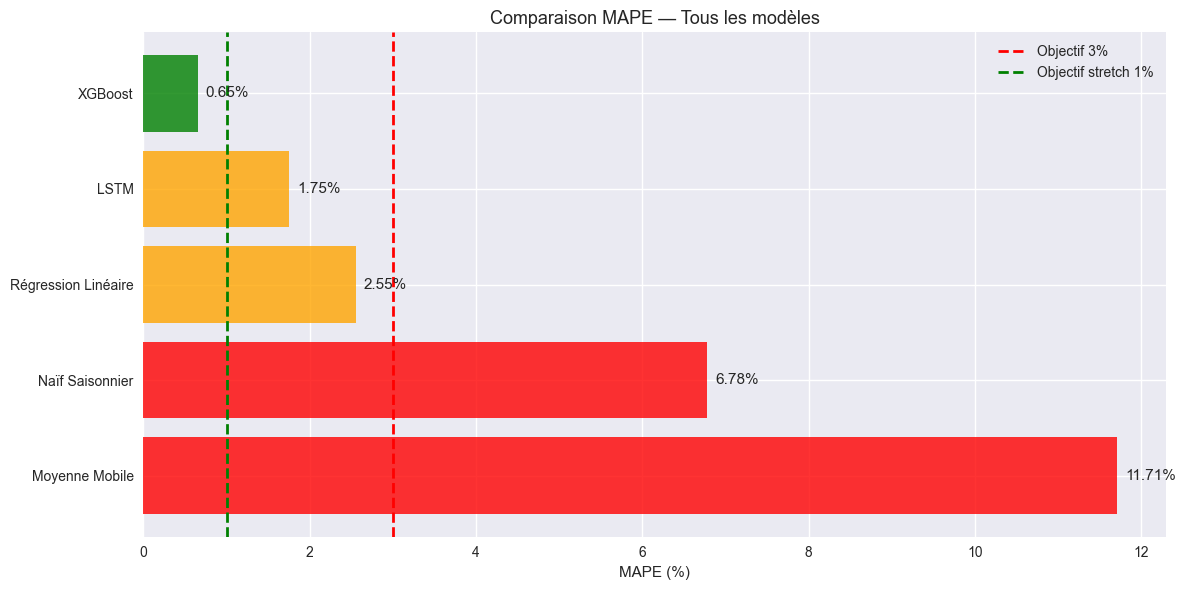

In [10]:
# ============================================================
# Comparaison finale de tous les modèles
# ============================================================

df_resultats = pd.DataFrame([
    {'Modèle': 'Moyenne Mobile',      'MAPE': 11.71, 'MAE': 3543, 'RMSE': 4438},
    {'Modèle': 'Naïf Saisonnier',     'MAPE': 6.78,  'MAE': 2125, 'RMSE': 2917},
    {'Modèle': 'Régression Linéaire', 'MAPE': 2.55,  'MAE': 797,  'RMSE': 1015},
    {'Modèle': 'LSTM',                'MAPE': 1.75,  'MAE': 527,  'RMSE': 673},
    {'Modèle': 'XGBoost',             'MAPE': 0.65,  'MAE': 202,  'RMSE': 281},
]).sort_values('MAPE', ascending=False)

print("=== COMPARAISON FINALE ===")
print(df_resultats.to_string(index=False))

# Visualisation
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['red' if m > 3 else 'orange' if m > 1 else 'green' 
          for m in df_resultats['MAPE']]

bars = ax.barh(df_resultats['Modèle'], df_resultats['MAPE'], 
               color=colors, alpha=0.8)

ax.axvline(x=3, color='red', linestyle='--', 
           linewidth=2, label='Objectif 3%')
ax.axvline(x=1, color='green', linestyle='--', 
           linewidth=2, label='Objectif stretch 1%')

# Ajout des valeurs sur les barres
for bar, val in zip(bars, df_resultats['MAPE']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=11)

ax.set_title('Comparaison MAPE — Tous les modèles', fontsize=13)
ax.set_xlabel('MAPE (%)')
ax.legend()
plt.tight_layout()
plt.show()

# Sauvegarde
df_resultats.to_csv('../data/processed/resultats_tous_modeles.csv', index=False)

XGBoost est clairement le meilleur modèle, il est 10x plus précis que le naïf saisonnier et 4x mieux que la régression linéaire.

Le LSTM est bon mais moins performant que XGBoost sur ce notre dataset (tabulaires).

In [11]:
# ============================================================
# Sauvegarde des modèles
# ============================================================

import joblib

# Sauvegarde XGBoost
joblib.dump(model_xgb_opt, '../data/processed/model_xgboost.pkl')

# Sauvegarde LSTM
model_lstm.save('../data/processed/model_lstm.keras')

# Sauvegarde du scaler
joblib.dump(scaler_X, '../data/processed/scaler_X.pkl')
joblib.dump(scaler_y, '../data/processed/scaler_y.pkl')

print(" Modèles sauvegardés :")
print("  - data/processed/model_xgboost.pkl")
print("  - data/processed/model_lstm.keras")
print("  - data/processed/scaler_X.pkl")
print("  - data/processed/scaler_y.pkl")

 Modèles sauvegardés :
  - data/processed/model_xgboost.pkl
  - data/processed/model_lstm.keras
  - data/processed/scaler_X.pkl
  - data/processed/scaler_y.pkl
